# Monte Carlo Option Pricing Model

## Objective
This notebook implements a Monte Carlo simulation to price European call and put options. 
The results are compared with the analytical solution from the Black-Scholes model to validate accuracy.

We also explore convergence behavior, payoff distributions, and simulated price paths.

## Mathematical Background

We assume that the stock price follows Geometric Brownian Motion:

S_T = S_0 * exp((r - 0.5σ²)T + σ√T Z)

Where:
- S₀ = initial stock price
- r = risk-free rate
- σ = volatility
- T = time to maturity
- Z ~ N(0,1)

The option price is computed as the discounted expected payoff:

Price = exp(-rT) * E[max(S_T - K, 0)]

## Model Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt, log
from scipy.stats import norm

## Monte Carlo Pricing Function

In [2]:
import numpy as np

def monte_carlo_option_price(S0, K, T, r, sigma, n_simulations=100000, option_type="call"):
    # Step 1: Generate random standard normal values
    Z = np.random.randn(n_simulations)
    
    # Step 2: Simulate terminal stock prices
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Step 3: Calculate payoffs
    if option_type == "call":
        payoffs = np.maximum(ST - K, 0)
    elif option_type == "put":
        payoffs = np.maximum(K - ST, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    # Step 4: Discount the average payoff
    option_price = np.exp(-r * T) * np.mean(payoffs)
    
    return option_price

# Example usage
price = monte_carlo_option_price(S0=100, K=100, T=1, r=0.05, sigma=0.2)
print("Estimated Option Price:", price)

Estimated Option Price: 10.489603864408055


## Black-Scholes Validation

We compute the analytical option price using the Black-Scholes model and compare it with the Monte Carlo estimate to validate accuracy.

In [3]:
from scipy.stats import norm
import numpy as np

def black_scholes_option_price(S0, K, T, r, sigma, option_type="call"):
    # Step 1: Compute d1 and d2
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Step 2: Calculate option price
    if option_type == "call":
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    return price

# Parameters
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

# Monte Carlo price
mc_price = monte_carlo_option_price(S0, K, T, r, sigma)

# Black-Scholes price
bs_price = black_scholes_option_price(S0, K, T, r, sigma)

# Output comparison
print("Monte Carlo Price:", mc_price)
print("Black-Scholes Price:", bs_price)
print("Absolute Error:", abs(mc_price - bs_price))

Monte Carlo Price: 10.458260010086741
Black-Scholes Price: 10.450583572185565
Absolute Error: 0.007676437901176669


## Confidence Interval
We estimate the uncertainty of the Monte Carlo result.

In [25]:
asian_price, asian_payoffs = asian_option_price(paths, K, r, T)

In [26]:
mean = np.mean(asian_payoffs)
std = np.std(asian_payoffs)

ci_low = np.exp(-r*T) * (mean - 1.96 * std / np.sqrt(len(asian_payoffs)))
ci_high = np.exp(-r*T) * (mean + 1.96 * std / np.sqrt(len(asian_payoffs)))

print("95% Confidence Interval:", (ci_low, ci_high))

95% Confidence Interval: (np.float64(0.11041292826913275), np.float64(8.383686141907043))


## Convergence Analysis
This plot shows how the Monte Carlo estimate stabilizes as the number of simulations increases.

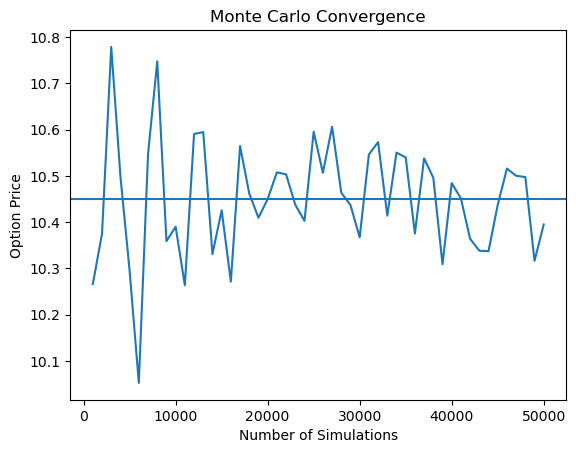

In [6]:
estimates = []
sim_range = range(1000, 50001, 1000)

for n in sim_range:
    Z = np.random.randn(n)
    ST = S0 * np.exp((r - 0.5 * sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs_temp = np.maximum(ST - K, 0)
    price = np.exp(-r*T) * np.mean(payoffs_temp)
    estimates.append(price)

plt.plot(sim_range, estimates)
plt.axhline(bs_price)
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")
plt.title("Monte Carlo Convergence")
plt.show()

In [ ]:
def confidence_interval(payoffs, r, T):
    discounted = np.exp(-r*T) * payoffs
    mean = np.mean(discounted)
    std = np.std(discounted)
    
    ci_low = mean - 1.96 * std / np.sqrt(len(payoffs))
    ci_high = mean + 1.96 * std / np.sqrt(len(payoffs))
    
    return mean, (ci_low, ci_high)

Multi-Step Path Simulation

In [ ]:
def simulate_paths(S0, T, r, sigma, steps, n_simulations):
    dt = T / steps
    
    paths = np.zeros((n_simulations, steps + 1))
    paths[:, 0] = S0
    
    for t in range(1, steps + 1):
        Z = np.random.randn(n_simulations)
        paths[:, t] = paths[:, t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * Z
        )
    
    return paths

Asian Options (Path-Dependent)
Payoff:
max(average price−K,0)

In [ ]:
def asian_option_price(paths, K, r, T):
    avg_price = np.mean(paths[:, 1:], axis=1)
    payoffs = np.maximum(avg_price - K, 0)
    
    return np.exp(-r*T) * np.mean(payoffs)

In [ ]:
Barrier Options (Path Logic)
Example :Up-and-Out Call
If price ever exceeds barrier → option = 0

In [ ]:
def barrier_option_price(paths, K, B, r, T):
    max_price = np.max(paths, axis=1)
    
    knocked_out = max_price >= B
    
    ST = paths[:, -1]
    payoffs = np.maximum(ST - K, 0)
    
    payoffs[knocked_out] = 0
    
    return np.exp(-r*T) * np.mean(payoffs)

Benchmarking

In [ ]:
import time

def benchmark():
    start = time.time()
    mc_price = monte_carlo_option_price(100, 100, 1, 0.05, 0.2, 100000)
    mc_time = time.time() - start

    start = time.time()
    anti_price = monte_carlo_antithetic(100, 100, 1, 0.05, 0.2, 100000)
    anti_time = time.time() - start

    print("Standard MC:", mc_price, "Time:", mc_time)
    print("Antithetic MC:", anti_price, "Time:", anti_time)

ASIAN OPTIONS

In [19]:
def asian_option_price(paths, K, r, T):
    avg_price = np.mean(paths[:, 1:], axis=1)
    payoffs = np.maximum(avg_price - K, 0)

    price = np.exp(-r*T) * np.mean(payoffs)

    return price, payoffs


asian_price, asian_payoffs = asian_option_price(paths, K, r, T)

print("Asian Option Price:", asian_price)


Asian Option Price: 5.85174160805486


## ASIAN PAYOFF DISTRIBUTION


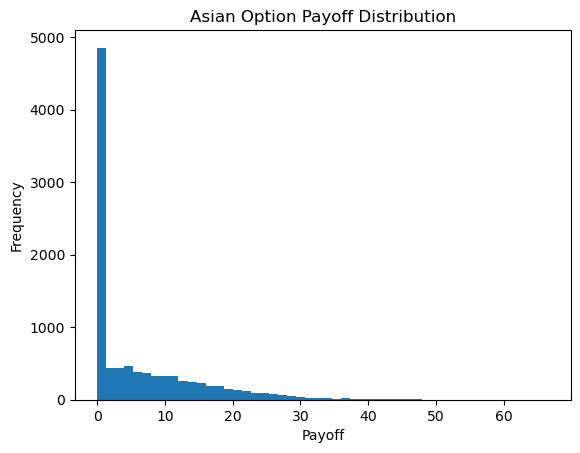

In [20]:


plt.figure()
plt.hist(asian_payoffs, bins=50)
plt.title("Asian Option Payoff Distribution")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.show()



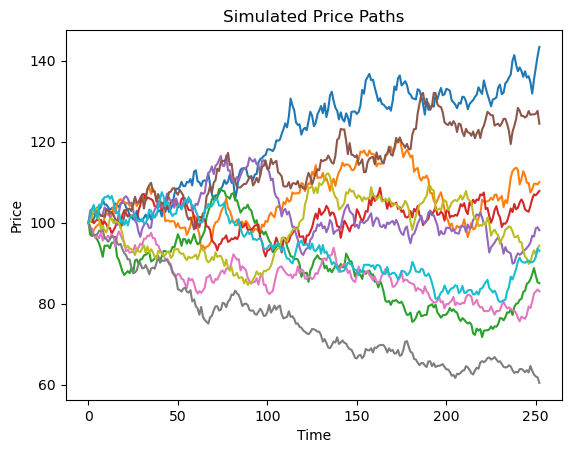

In [21]:
steps = 252
dt = T / steps
paths = np.zeros((10, steps + 1))
paths[:, 0] = S0

for t in range(1, steps + 1):
    Z = np.random.randn(10)
    paths[:, t] = paths[:, t-1] * np.exp(
        (r - 0.5 * sigma**2)*dt + sigma*np.sqrt(dt)*Z
    )

for i in range(10):
    plt.plot(paths[i])

plt.title("Simulated Price Paths")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Conclusion

- Monte Carlo simulation provides a flexible method for option pricing.
- The results converge to the Black-Scholes price as simulations increase.
- Confidence intervals quantify estimation uncertainty.
- Monte Carlo is especially useful for path-dependent options.

Future improvements include variance reduction techniques and pricing more complex derivatives such as Asian and barrier options.